In [1]:
import os
import json
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from tqdm.notebook import tqdm, trange
import numpy as np
from torch.utils.data.sampler import SubsetRandomSampler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F
from itertools import cycle

In [2]:
DATA_DIR = "../data/combined-dataset-16class"
WEIGHTS_PATH = f"{DATA_DIR}/class_weights.json"
NUM_CLASSES = 16
MODEL_NAME = "mlp_regularized"
IMAGE_SIZE = 64
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


In [4]:
class MLP_Regularized(nn.Module):
    def __init__(self, num_classes=16):
        super(MLP_Regularized, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(12288, 1024), 
            nn.ReLU(), 
            nn.Dropout(0.4),
            
            nn.Linear(1024, 256), 
            nn.ReLU(), 
            nn.Dropout(0.4),
            
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.network(self.flatten(x))

In [5]:
train_transform = [
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]

In [6]:
eval_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [7]:
train_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=transforms.Compose(train_transform))
val_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/train", transform=eval_transform) 

In [9]:
dataset_size = len(train_dataset)
indices = list(range(dataset_size))
split = int(np.floor(0.2 * dataset_size))

np.random.seed(42)
np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(train_indices), num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=SubsetRandomSampler(val_indices), num_workers=4, pin_memory=True)

In [11]:
print(f"Loading data at resolution: {IMAGE_SIZE}x{IMAGE_SIZE}.")
print(f"Train Size: {len(train_indices)} | Val Size: {len(val_indices)}")

Loading data at resolution: 64x64.
Train Size: 1968 | Val Size: 491


In [13]:
model = MLP_Regularized(NUM_CLASSES)
print(f"Initializing {MODEL_NAME.upper()}...")
model = model.to(device)

Initializing MLP_REGULARIZED...


In [14]:
with open(WEIGHTS_PATH, "r") as f:
    weight_dict = json.load(f)

class_names = train_dataset.classes
weights_list = [weight_dict[c] for c in class_names]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float32).to(device)

In [15]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [16]:
patience = 5
best_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

In [17]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [18]:
start_time = time.time()

epoch_pbar = trange(NUM_EPOCHS, desc=f"Training {MODEL_NAME.upper()}", unit="epoch")

for epoch in epoch_pbar:
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
        else:
            model.eval()
            dataloader = val_loader

        running_loss = 0.0
        running_corrects = 0
        dataset_size = len(dataloader.sampler)

        batch_pbar = tqdm(dataloader, desc=f"Epoch {epoch+1} [{phase.capitalize()}]", leave=False)

        for inputs, labels in batch_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            batch_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc.item())
            
            tqdm.write(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                       f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | "
                       f"Val Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

    if patience_counter >= patience:
        tqdm.write(f"Early stopping triggered at epoch {epoch+1}!")
        break

time_elapsed = time.time() - start_time
print(f'\n{MODEL_NAME.upper()} Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

Training MLP_REGULARIZED:   0%|          | 0/30 [00:00<?, ?epoch/s]

Epoch 1 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 3.5963 Acc: 0.0859 | Val Loss: 3.3078 Acc: 0.0957


Epoch 2 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

...

Epoch 21 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 21/30 | Train Loss: 2.6610 Acc: 0.0838 | Val Loss: 2.7284 Acc: 0.0570


Epoch 22 [Train]:   0%|          | 0/31 [00:00<?, ?it/s]

Epoch 22 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 22/30 | Train Loss: 2.6312 Acc: 0.0864 | Val Loss: 2.7065 Acc: 0.0672
Early stopping triggered at epoch 22!

MLP_REGULARIZED Training complete in 7m 9s


In [19]:
os.makedirs("../models", exist_ok=True)
os.makedirs(f"../models/{MODEL_NAME}", exist_ok=True)
save_path = f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pth"
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), save_path)
print(f"Best weights saved to {save_path}")

Best weights saved to ../models/mlp_regularized/mlp_regularized_best.pth


In [20]:
MODEL_WEIGHTS_PATH = f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pth"

print(f"Evaluating on device: {device}")
sns.set_theme(style="whitegrid")

Evaluating on device: cuda


In [21]:
test_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [22]:
test_dataset = datasets.ImageFolder(root=f"{DATA_DIR}/test", transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [23]:
class_names = test_dataset.classes
print(f"Loaded {len(test_dataset)} test images across {len(class_names)} classes.")

Loaded 322 test images across 16 classes.


In [24]:
def load_trained_model(model_name, num_classes, weights_path, device):
    """Initializes the architecture and loads saved weights."""
    if model_name == 'mlp_shallow':
        model = MLP_Shallow(num_classes=num_classes)
        
    elif model_name == 'mlp_regularized':
        model = MLP_Regularized(num_classes=num_classes)
        
    elif model_name == 'cnn_baseline':
        model = CNN_Baseline(num_classes=num_classes)
        
    elif model_name == 'cnn_advanced':
        model = CNN_Advanced(num_classes=num_classes)
        
    else:
        raise ValueError(f"Unknown model architecture: {model_name}")

    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

In [25]:
model = load_trained_model(MODEL_NAME, NUM_CLASSES, MODEL_WEIGHTS_PATH, device)
print(f"Successfully loaded {MODEL_NAME} weights from disk.")

Successfully loaded mlp_regularized weights from disk.


/tmp/ipykernel_50911/2156170029.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


In [26]:
def evaluate_model(model, dataloader, classes, device):
    all_preds = []
    all_labels = []
    all_probs = []
    
    print("Generating predictions...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Print Classification Report
    print("\n" + "="*50)
    print(f"CLASSIFICATION REPORT: {MODEL_NAME.upper()}")
    print("="*50)
    report_text = classification_report(all_labels, all_preds, target_names=classes, digits=4)
    print(report_text)

    os.makedirs("../visualizations", exist_ok=True)
    os.makedirs(f"../visualizations/{MODEL_NAME}", exist_ok=True)
    with open(f"../visualizations/{MODEL_NAME}/report.txt", "w") as f:
        f.write(f"Classification Report for {MODEL_NAME.upper()}\n\n")
        f.write(report_text)
        
    report_dict = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)
    df_report = pd.DataFrame(report_dict).transpose()
    df_report.to_csv(f"../visualizations/{MODEL_NAME}/report.csv")
    print(f"Metrics saved to ../visualizations/{MODEL_NAME}/report.csv")
    
    # 2. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Number of Images'})
    
    plt.title(f'Confusion Matrix: {MODEL_NAME.upper()}', fontsize=16, pad=20)
    plt.ylabel('True Label', fontsize=12, labelpad=10)
    plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"../visualizations/{MODEL_NAME}/confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.show()

    n_classes = len(classes)
    y_bin = label_binarize(all_labels, classes=range(n_classes))
    all_probs = np.array(all_probs)
    
    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    # --- PLOTTING THE ROC CURVE ---
    plt.figure(figsize=(12, 10))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow', 'brown', 'pink', 'gray', 'olive', 'lime', 'teal', 'navy', 'maroon'])
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of {0} (area = {1:0.2f})'.format(classes[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal guessing line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title(f'Multi-Class ROC Curve: {MODEL_NAME.upper()}', fontsize=16)
    
    # Put legend outside the plot so it doesn't cover the lines
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
    plt.tight_layout()
    
    plt.savefig(f"../visualizations/{MODEL_NAME}/{MODEL_NAME}_roc_curve.png", dpi=300, bbox_inches='tight')
    plt.show()

Generating predictions...

CLASSIFICATION REPORT: MLP_REGULARIZED
                            precision    recall  f1-score   support

                Apple Leaf     0.2250    0.4500    0.3000        20
           Apple Rust Leaf     0.2222    0.1250    0.1600        32
           Apple Scab leaf     0.0000    0.0000    0.0000        32
       Corn Gray Leaf Spot     0.0000    0.0000    0.0000        15
                 Corn Leaf     0.0667    0.3636    0.1127        11
          Corn Leaf Blight     0.0952    0.0870    0.0909        23
            Corn Rust Leaf     0.1667    0.0476    0.0741        21
        Potato Leaf Blight     0.0000    0.0000    0.0000        27
     Potato Leafroll Virus     0.0417    0.3636    0.0748        11
               Tomato Leaf     0.0000    0.0000    0.0000        19
Tomato Leaf Bacterial Spot     0.0000    0.0000    0.0000        20
  Tomato Leaf Early Blight     0.0000    0.0000    0.0000        20
   Tomato Leaf Late Blight     0.0000    0.0000  

/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jagujay/miniconda3/envs/ml-dl/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

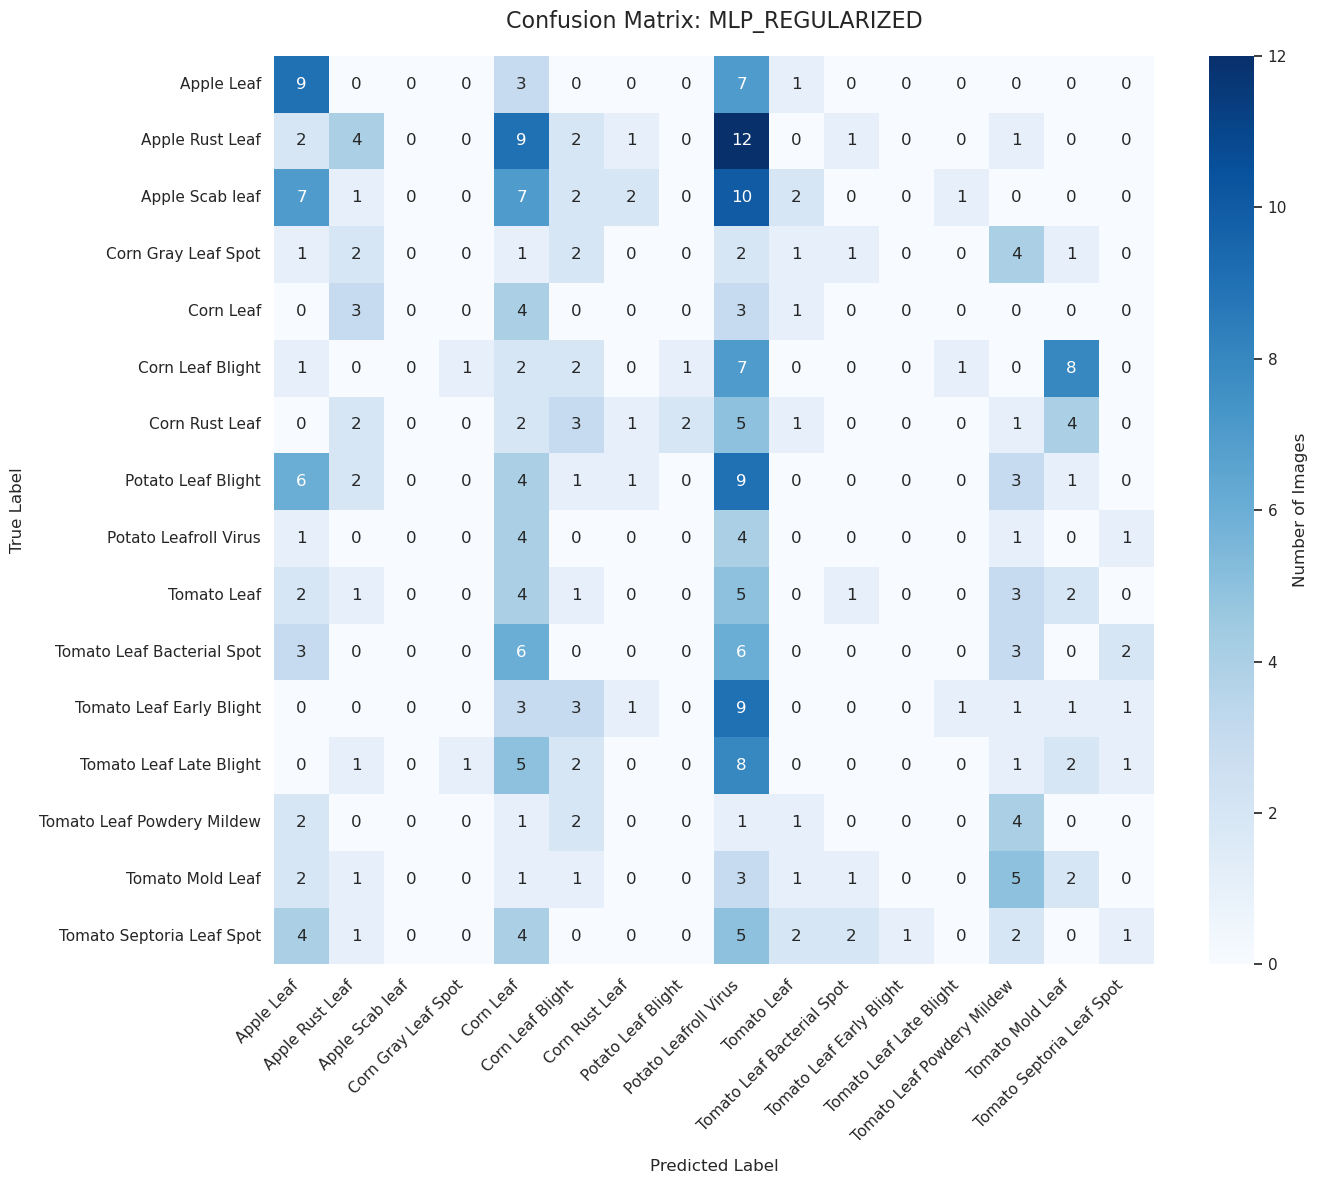

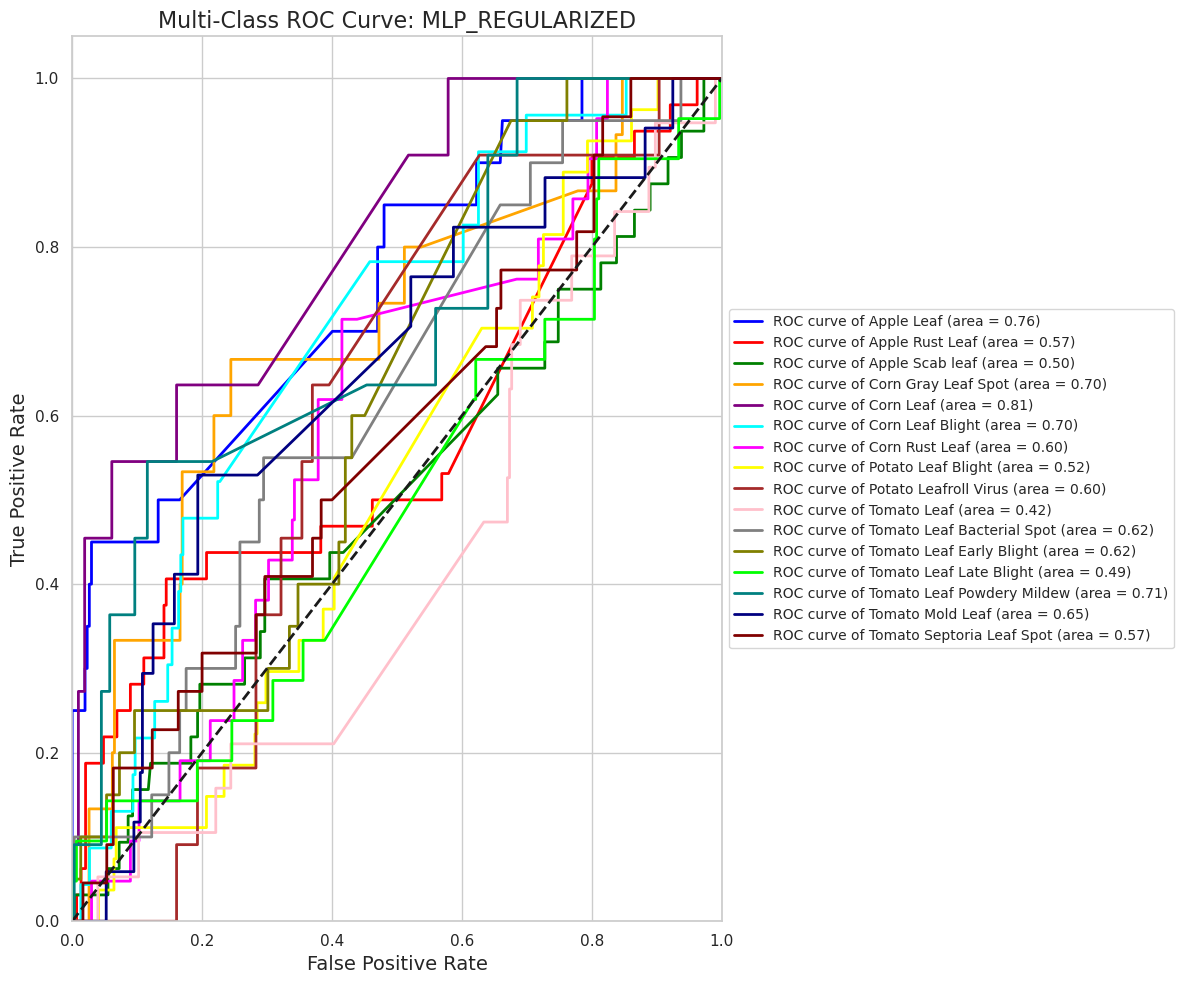

In [27]:
evaluate_model(model, test_loader, class_names, device)